In [1]:
import pandas as pd
import os

import graphviz
import cairosvg

# DATA LOADING

In [2]:
df_adv = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "processed", "data_topic_weights.csv"))
df_obs = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "processed", "data_obs.csv"))
df_obs.drop(df_obs.columns[0], axis=1, inplace=True)
df_obs["condition"] = "OBS"
df_adv["condition"] = "ADV"
df = pd.concat([df_obs, df_adv])
id_to_topic = df.set_index("ID")["assigned_topic"].to_dict()
df["parent_assigned_topic"] = df["parent_ID"].map(id_to_topic)
df.tail()

,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,gen,parent_ID,...,assigned_topic,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_assigned_topic
995,668a935e677dc562a445cd03,0.379820,0.281283,0.478356,0.247881,80,053402_experiment_2024-07-10_19h18.39.977.csv,0.558594,10,5f43bbbc0dab3463a47b93e0,...,2.0,0.169108,0.068684,0.330074,0.063610,0.261180,0.008401,0.000000,0.098943,2.0
996,668bb99e5fa8b9ebb3c428ac,0.237887,0.201746,0.274028,-0.082329,91,909045_experiment_2024-07-10_18h48.16.190.csv,0.519531,10,6658c10539f5e53a96a6ad40,...,7.0,0.484727,0.000000,0.265923,0.000000,0.000000,0.000000,0.000000,0.249351,7.0
997,668bfbcbfd735b6652c60f20,-0.116250,-0.155149,-0.077350,0.732068,61,489637_experiment_2024-07-10_14h22.18.159.csv,0.542969,10,5a9bf9bd89de8200013f0f28,...,2.0,0.133815,0.118867,0.270629,0.089777,0.251170,0.002137,0.037103,0.096502,2.0
998,668d5331aa58b7e75ff160d7,0.091113,0.161720,0.020506,0.714286,63,234906_experiment_2024-07-10_19h00.46.327.csv,0.609375,10,5c436d365140ec0001030b05,...,1.0,0.047872,0.229925,0.189555,0.279478,0.132181,0.090450,0.030539,0.000000,1.0
999,668d822d705c807ed4664ae1,0.820187,0.642993,0.997381,2.688492,5,564113_experiment_2024-07-10_18h59.42.430.csv,0.730469,10,66730795fa560aa138fc5f91,...,2.0,0.132785,0.038407,0.357090,0.069165,0.281337,0.015952,0.003242,0.102021,2.0


# ADV Viz

In [3]:
def get_descendants(target_id, df):
    """ Recursively retrieve all descendants of a given target_id """
    descendants = set()
    children = df[df["parent_ID"] == target_id]["ID"]
    
    for child in children:
        descendants.add(child)
        descendants.update(get_descendants(child, df))  # Recursively find their descendants
    
    return descendants

target_id = "5da83385e8bf0200113c3c6e"  # Replace with the actual ID you want to track

descendant_ids = get_descendants(target_id, df_adv)

df_adv = df[df["condition"] == "ADV"]
# Filter dataset to keep only descendants of the given ID
df_filtered = df_adv[df_adv["ID"].isin(descendant_ids) | (df_adv["ID"] == target_id)]
df_filtered.loc[df_filtered["assigned_topic"] > 5, "assigned_topic"] = -1
df_filtered.loc[df_filtered["parent_assigned_topic"] > 5, "parent_assigned_topic"] = -1

df_filtered.head()

,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,gen,parent_ID,...,assigned_topic,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_assigned_topic
30,5da83385e8bf0200113c3c6e,0.239786,0.310415,0.169156,0.452941,33,599389_experiment_2024-05-15_18h51.00.136.csv,0.597656,1,fake 59,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108,5a598f2b8e6259000175f094,0.344362,0.641733,0.046991,1.486220,6,069011_experiment_2024-05-21_18h46.17.494.csv,0.656250,2,5da83385e8bf0200113c3c6e,...,0.0,0.385061,0.066050,0.111537,0.092714,0.078247,0.000000,0.116819,0.149572,0.0
115,5bdead73ed3acf0001666f03,0.529609,1.000000,0.059219,1.914226,2,159331_experiment_2024-05-21_18h50.24.429.csv,0.644531,2,5da83385e8bf0200113c3c6e,...,0.0,0.385061,0.066050,0.111537,0.092714,0.078247,0.000000,0.116819,0.149572,0.0
151,5fde8fc3c0e40a651914c261,0.033581,0.126190,-0.059028,0.071429,58,047304_experiment_2024-05-21_19h08.15.176.csv,0.578125,2,5da83385e8bf0200113c3c6e,...,0.0,0.385061,0.066050,0.111537,0.092714,0.078247,0.000000,0.116819,0.149572,0.0
203,5a031341728b1b0001ad8bee,0.145337,0.284193,0.006481,0.037698,65,859317_experiment_2024-05-22_19h04.42.208.csv,0.578125,3,5a598f2b8e6259000175f094,...,1.0,0.347300,0.133561,0.134979,0.122608,0.110262,0.020961,0.047533,0.082796,0.0


In [ ]:
dot = graphviz.Digraph("adv-lineage")
dot.attr('graph', ranksep='40.0', nodesep='2.0')
dot.attr('node', width='10', height='10', fontsize='14', fixedsize='true')

def darken_hex(hex_color, factor=0.8):
    """Darkens a hex color by multiplying RGB values by the factor (0 < factor < 1)."""
    hex_color = hex_color.lstrip('#')
    rgb = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    dark_rgb = [max(0, int(c * factor)) for c in rgb]
    return '#{:02x}{:02x}{:02x}'.format(*dark_rgb)

topic_shapes = {
    -1: "circle",
    0: "triangle",
    1: "square",
    2: "pentagon",
    3: "circle",
    4: "hexagon",
    5: "diamond"
}

topic_colors = {
    -1: "gray",
    # 0: "#F4E285",
    0: "#D4AF37",
    1: "#F4A259",
    2: "#5B8E7D",
    3: "#BC4B51",
    4: "#8CB369",
    5: "#6C5B7B"
}


for row in df_filtered.iterrows():
    ID = row[1]["ID"]
    if ID == "5da83385e8bf0200113c3c6e":
        continue
    pID = row[1]["parent_ID"]
    topic = row[1]["parent_assigned_topic"]
    color = topic_colors[topic]
    dot.attr("edge", penwidth="80.0", color=color)
    dot.edge(pID, ID)

for row in df_filtered.iterrows():
    ID = row[1]["ID"]
    topic = row[1]["assigned_topic"]
    shape = topic_shapes[topic]
    color = topic_colors[topic]
    dot.node(ID, label="", shape=shape, color=color, style="filled", fillcolor=color, penwidth="20")



output_dir = os.path.join(os.path.dirname(os.getcwd()), "output", "figures", "manuscript")
output_path = os.path.join(output_dir, "test")
# svg_path = dot.render(directory=output_path, format="svg").replace('\\', '/')
# png_path = output_path + "_hires.png"
# cairosvg.svg2png(
#     url=svg_path,
#     write_to=png_path,
#     dpi=300,
#     output_width = 2550,
#     output_height = 1200
# )
pdf_path = dot.render(directory=output_path, format="pdf").replace('\\', '/')

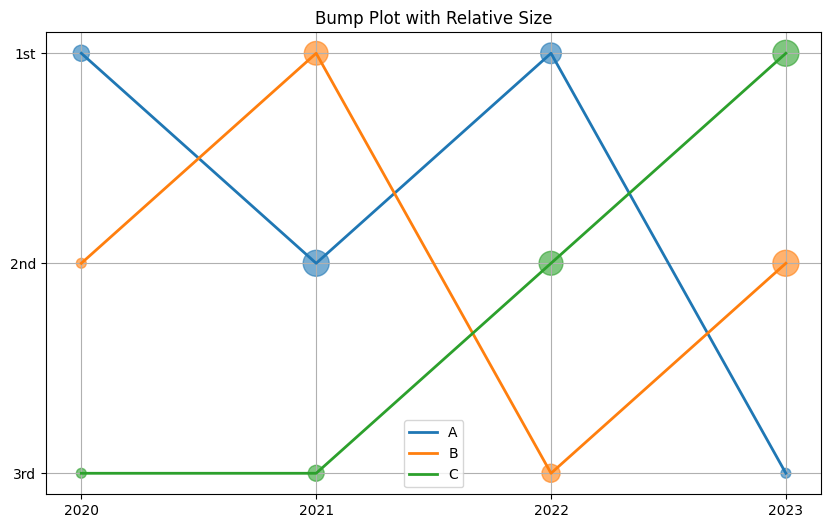

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data: ranks over time for different categories
data = {
    'Year': [2020, 2021, 2022, 2023],
    'A': [1, 2, 1, 3],
    'B': [2, 1, 3, 2],
    'C': [3, 3, 2, 1],
    'Size_A': [100, 150, 120, 80],
    'Size_B': [90, 130, 110, 140],
    'Size_C': [70, 100, 160, 180]
}

df = pd.DataFrame(data)

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize sizes for plotting
def normalize(sizes, scale=300):
    sizes = pd.Series(sizes)
    return scale * (sizes - sizes.min()) / (sizes.max() - sizes.min()) + 50

# Plot each category
for label in ['A', 'B', 'C']:
    ax.plot(df['Year'], df[label], label=label, linewidth=2)
    sizes = normalize(df[f'Size_{label}'])
    ax.scatter(df['Year'], df[label], s=sizes, alpha=0.6)

# Invert y-axis to show rank properly
ax.invert_yaxis()
ax.set_xticks(df['Year'])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['1st', '2nd', '3rd'])
ax.set_title("Bump Plot with Relative Size")
ax.legend()
plt.grid(True)
plt.show()
